In [1]:
import pandas as pd
import numpy as np
from pathlib import Path


records = []
yymmdd = '240813'
cell = 'cell0001'
spine_types = ['BLA', 'CA3']
main_matrix_ids = [] # ['M1', 'M2'] # , 'mm6', 'mm7']
for i in range(1,21):
    id = str(i)
    m_id = 'M' + id
    main_matrix_ids.append(m_id)

date_str = '05_09_2026_sanity_check'

for main_matrix_id in main_matrix_ids:      # nuovo loop esterno

    for spine_type in spine_types:

        # --- experiment ---
        data_path_exp = Path('D:/') / f"{yymmdd}_{cell}_{spine_type}_{main_matrix_id}_{date_str}_experiment" / "output_soma_v"
        for file in sorted(data_path_exp.glob("*.npy")):

            records.append({
                "main_matrix_id": main_matrix_id,
                "date_str": date_str,
                "spine_type": spine_type,
                "condition": "experiment",
                "filename": file.name,
                "data": np.load(file),
                "path": file,
            })

        # --- random ---
        data_path_rnd = Path('D:/') / f"{yymmdd}_{cell}_{spine_type}_{main_matrix_id}_{date_str}" / "output_soma_v"
        for file in sorted(data_path_rnd.glob("*.npy")):
            if file.name.startswith("._"):
                continue
            records.append({
                "main_matrix_id": main_matrix_id,
                "date_str": date_str,
                "spine_type": spine_type,
                "condition": "random",
                "filename": file.name,
                "data": np.load(file, allow_pickle=True),
                "path": file,
            })

df = pd.DataFrame(records)


In [2]:
df.to_pickle("D:/dataset_M1_M20_30_08_2026_sanity_check.pkl") # li salva in un file .pkl

import pandas as pd
import numpy as np
from pathlib import Path

# df = pd.read_pickle("D:/dataset_M1_M20_30_08_2026.pkl")

aus_data = df.loc[
            (df["spine_type"] == 'CA3') &
            (df["main_matrix_id"] == 'M3') &
            (df["condition"] == 'experiment')
        ]

aus_data['data'].iloc[0] # il riferimento e' il Vm ottenuto applicando la main_matrix di input di ogni gruppo di mm


array([-66.        , -65.99607431, -65.99194679, ..., -66.78976574,
       -66.78368413, -66.77809621], shape=(32001,))

In [4]:
main_matrix_ids

['M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'M10',
 'M11',
 'M12',
 'M13',
 'M14',
 'M15',
 'M16',
 'M17',
 'M18',
 'M19',
 'M20']

In [5]:
spine_types = ['BLA', 'CA3']
#main_matrix_ids = ['mm3', 'mm4', 'mm5', 'mm6', 'mm7']
# main_matrix_ids = ['M1', 'M2']
cond = ['experiment']
# spine_types
# main_matrix_ids
distances_exp = {}
ref_Vs = {}
for mm in main_matrix_ids:
    for SpineType in spine_types:
        aus_data = df.loc[
            (df["spine_type"] == SpineType) &
            (df["main_matrix_id"] == mm) &
            (df["condition"] == 'experiment')
        ]
        ref_V = aus_data['data'].iloc[0] # il riferimento e' il Vm ottenuto applicando la main_matrix di input di ogni gruppo di mm
        ref_Vs[SpineType,mm,'experiment'] = ref_V
        aus_distances = []
        for k in aus_data['data'][1:]: # qui va bene perche' escludo il primo set di Vm che e' quello di riferimento, altrimenti la differenza tra Vm e se stesso viene 0
            aus_d = np.sqrt(np.sum((k - ref_V)**2))
            aus_distances.append(aus_d)
        distances_exp[(SpineType, mm, 'experiment')] = aus_distances


In [6]:
spine_types = ['BLA', 'CA3']
# main_matrix_ids = ['mm3'] # , 'mm4', 'mm5', 'mm6', 'mm7']

cond = ['random']
# spine_types
# main_matrix_ids
distances_sim = {}
ref_Vs = {}

n_Vm_per_assign = 50
for mm in main_matrix_ids:
    for SpineType in spine_types:
        aus_data = df.loc[
            (df["spine_type"] == SpineType) &
            (df["main_matrix_id"] == mm) &
            (df["condition"] == 'random')
        ]

        data_values = aus_data['data'].to_numpy()

        # lista con i 21 ref_V. Ho 21 riassegnazioni di BLA e CA3. Prendo come rifrimento il primo Vm di output ottenuto applicando la prima matrice di input alla prima riassegnazione delle spine, prima di fare le permutazioni delle righe della matrice
        ref_Vs[(SpineType, mm, 'random')] = []

        # lista di tutte le distanze
        aus_distances = []

        # 21 gruppi (che corrispondono alle 21 riassegnazioni delle spine) da 50 file (50 permutazioni della matrice di input per ogni riassegnazione delle spine)
        for i in range(0, len(data_values), n_Vm_per_assign):

            # primo file di ogni gruppo = ref_V
            ref_V = data_values[i]

            ref_Vs[(SpineType, mm, 'random')].append(ref_V)

            # i successivi 49 file vengono confrontati con questo ref_V
            for k in data_values[i + 1:i + n_Vm_per_assign]:

                aus_d = np.sqrt(np.sum((k - ref_V) ** 2))
                aus_distances.append(aus_d)

        distances_sim[(SpineType, mm, 'random')] = aus_distances


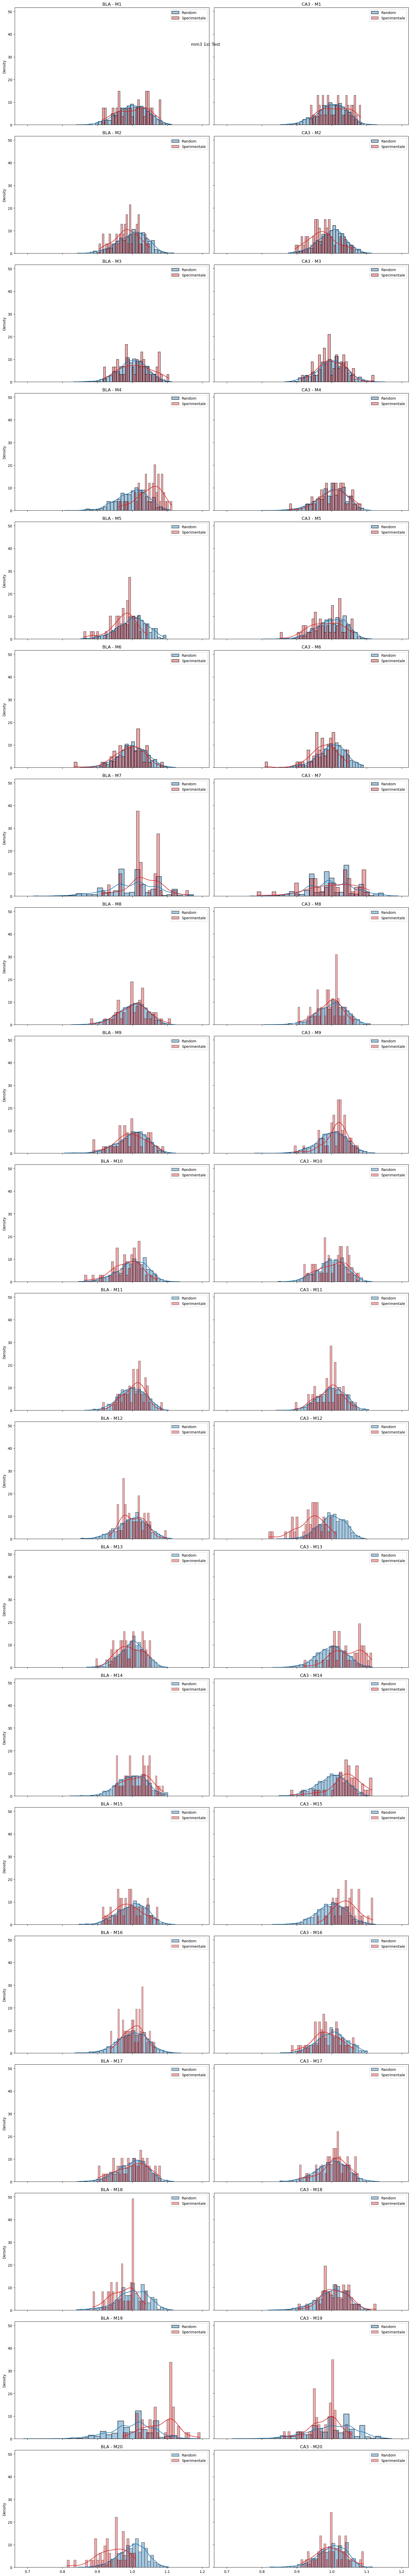

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
# mms = ['mm3'] # , 'mm4', 'mm5','mm6','mm7']
regions = ['BLA', 'CA3']
mms = main_matrix_ids
subplot_w = 8
subplot_h = 5
fig, axes = plt.subplots(
    len(mms), 2,
    figsize=(2* subplot_w, len(mms) * subplot_h),
    #figsize=(60, 30),
    sharex=True,
    sharey=True
)
fig.suptitle('mm3 1st Test')
for i, mm in enumerate(mms):
    for j, region in enumerate(regions):

        ax = axes[i,j]

        random_data = np.array(
            distances_sim[region, mm, 'random']
        )

        # dati sperimentali
        exp_data = np.array(
            distances_exp[region, mm, 'experiment']
        )

            # media random
        mu = np.mean(random_data)

        # normalizzazione
        d_sim = random_data / mu
        d_exp = exp_data / mu
        sns.histplot(
            d_sim,
            kde=True,
            stat='density',
            bins=30,
            alpha=0.4,
            label='Random',
            color='tab:blue',
            ax=ax
        )
        sns.histplot(
            d_exp,
            kde=True,
            stat='density',
            bins=30,
            alpha=0.4,
            label='Sperimentale',
            color='tab:red',
            ax=ax
        )
        ax.legend()
        ax.set_title(f'{region} - {mm}')

#plt.xlim([0.75, 1.15])
#plt.ylim([0, 40])

plt.tight_layout()
plt.show()

In [15]:
'''all_d = {}
for j, region in enumerate(regions):
    all_d[(region)] = []
    for i, mm in enumerate(mms):
        d_exp = distances_exp[region,mm,'experiment']
        d_sim = distances_sim[region,mm,'random']

        all_d[(region)].append((d_sim, d_exp))

import numpy as np
'''
all_d = {}
for region in regions:
    d_sim_all = []
    d_exp_all = []

    for mm in mms:
        d_exp = distances_exp[region, mm, 'experiment']
        d_sim = distances_sim[region, mm, 'random']

        mu = np.mean(d_sim)

        d_sim_all.append(d_sim/mu)
        d_exp_all.append(d_exp/mu)

    all_d[region] = {
    'sim': np.array(d_sim_all),
    'exp': np.array(d_exp_all)
}


#all_d_exp_arr = np.array(all_d_exp)
#alld_sim_arr = np.array(all_d_sim)

In [16]:
all_d_sim_BLA = all_d['BLA']['sim']

all_d_exp_BLA = all_d['BLA']['exp']

all_d_exp_CA3 = all_d['CA3']['exp']
all_d_sim_CA3 = all_d['CA3']['sim']

In [17]:
all_d_exp_BLA = np.asarray(all_d_exp_BLA).flatten()
all_d_sim_BLA = np.asarray(all_d_sim_BLA).flatten()

all_d_exp_CA3 = np.asarray(all_d_exp_CA3).flatten()
all_d_sim_CA3 = np.asarray(all_d_sim_CA3).flatten()


In [18]:
'''
mu_BLA = np.mean(all_d_sim_BLA)
mu_CA3 = np.mean(all_d_sim_CA3)

# normalizzazione
d_sim_BLA = all_d_sim_BLA / mu_BLA
d_exp_BLA = all_d_exp_BLA / mu_BLA

d_sim_CA3 = all_d_sim_CA3 / mu_CA3
d_exp_CA3 = all_d_exp_CA3 / mu_CA3

'''

'\nmu_BLA = np.mean(all_d_sim_BLA)\nmu_CA3 = np.mean(all_d_sim_CA3)\n\n# normalizzazione\nd_sim_BLA = all_d_sim_BLA / mu_BLA\nd_exp_BLA = all_d_exp_BLA / mu_BLA\n\nd_sim_CA3 = all_d_sim_CA3 / mu_CA3\nd_exp_CA3 = all_d_exp_CA3 / mu_CA3\n\n'

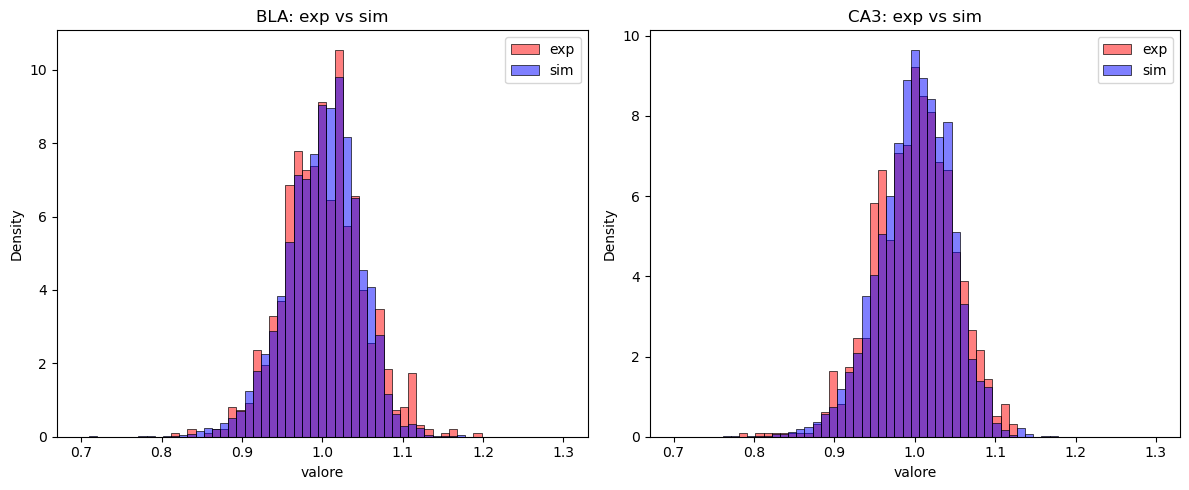

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bins_n= np.linspace(0.7,1.3,60)

# ----- istogramma BLA: exp vs sim sovrapposti -----
sns.histplot(all_d_exp_BLA, stat='density', label='exp', color='red', alpha=0.5, ax=axes[0],bins=bins_n)
sns.histplot(all_d_sim_BLA, stat='density', label='sim', color='blue', alpha=0.5, ax=axes[0],bins=bins_n)
axes[0].set_title('BLA: exp vs sim')
axes[0].set_xlabel('valore')
axes[0].legend()

# ----- istogramma CA3: exp vs sim sovrapposti -----
sns.histplot(all_d_exp_CA3, stat='density', label='exp', color='red', alpha=0.5, ax=axes[1],bins=bins_n)
sns.histplot(all_d_sim_CA3, stat='density', label='sim', color='blue', alpha=0.5, ax=axes[1],bins=bins_n)
axes[1].set_title('CA3: exp vs sim')
axes[1].set_xlabel('valore')
axes[1].legend()

np
plt.tight_layout()
plt.show()

In [20]:
"""
Lo shift lo definisco come posizione del picco della KDE -valore di un punto su x fissato
"""
from scipy.stats import gaussian_kde

def picco_kde_da_dati(dati, n_punti_valutazione=5000):
    """
    Calcolo la KDE dei dati come in seaborn e trovo la posizione del suo picco
    n_punti_valutazione ---> Risoluzione della griglia su cui si valuta la KDE: piu' punti = stima del picco piu' precisa.
    """
    dati = np.asarray(dati)
    kde = gaussian_kde(dati) # ----- kde

    # Griglia di valutazione
    margine = 0.1 * (dati.max() - dati.min())
    x_grid = np.linspace(dati.min() - margine, dati.max() + margine, n_punti_valutazione)
    y_grid = kde(x_grid)

    x_picco = x_grid[np.argmax(y_grid)] # ----- posizione del picco della curva

    return x_picco, kde,x_grid


def shift_kde_da_dati(punto_fissato, dati, n_punti_valutazione=5000):
    """
    Calcola lo shift del picco della KDE rispetto a un punto fissato, a partire dai dati
    """
    x_picco, kde, x_grid = picco_kde_da_dati(dati, n_punti_valutazione)
    return {
        "picco_kde": x_picco,
        "shift": x_picco - punto_fissato,
        "kde" : kde,
        "x_grid" : x_grid
    }



In [41]:
# aggiunte 04 09 2026
regions =  ['BLA', 'CA3']
all_mms = [] # ['M1', 'M2'] # , 'mm6', 'mm7']
for i in range(1,21):
    id = str(i)
    m_id = 'M' + id
    all_mms.append(m_id)

dati = {}
x0 = 1.0
dist_norm = {}
kde = {}
for i, mm in enumerate(all_mms):
    for j, region in enumerate(regions):

        random_data = np.array(
            distances_sim[region, mm, 'random']
        )

        # dati sperimentali
        #exp_data = np.array(
        #    distances_exp[region, mm, 'experiment']
        #)
        exp_data = np.array(
            distances_exp[region, mm, 'experiment']
        )

            # media random
        mu = np.mean(random_data)

        # normalizzazione
        d_sim = random_data / mu
        #d_exp = exp_data / mu
        d_exp = exp_data/ mu

        #dist_norm
        dist_norm[region, mm,'random'] = d_sim
        dist_norm[region,mm,'experiment'] = d_exp # shift_multiplo_da_dati(x0,d_exp)


In [42]:
dist_norm['BLA','M1','experiment']

array([0.9161786 , 0.92373811, 1.04954521, 0.97773484, 1.01862233,
       0.94302665, 0.97507407, 0.94808761, 1.08185544, 1.03749073,
       0.9792307 , 1.02603083, 0.95698274, 1.03790033, 0.99498862,
       0.96452729, 1.02915787, 1.0545008 , 0.961688  , 1.04634452,
       1.01934426, 1.04545522, 1.01647055, 0.95409302, 1.03877369,
       1.04489039, 1.00179478, 0.99549586, 0.96363277, 1.04039409,
       0.96147791, 0.91401361, 1.05915131, 1.03257932, 1.01087164,
       1.02116712, 1.05213138, 1.07825239, 1.02435611, 1.08099163,
       0.95914068, 0.98779827, 0.98985383, 1.01006145, 0.96515693,
       1.04354027, 0.94586092, 0.92378079])

In [43]:
distr = {}
conditions = ['experiment', 'random']
risultati = {}
x0 = 1.0
for (area, matrice, condition), dn in dist_norm.items():

    name = f'{area}_{matrice}_{condition}'
    #distr[name] = dn
    risultati[area,matrice,condition] = shift_kde_da_dati(x0, dn)


risultati['BLA','M1','experiment']


{'picco_kde': np.float64(1.031878932758171),
 'shift': np.float64(0.031878932758171),
 'kde': <scipy.stats._kde.gaussian_kde at 0x20bcf379780>,
 'x_grid': array([0.89722942, 0.89726971, 0.89731   , ..., 1.09855905, 1.09859934,
        1.09863963], shape=(5000,))}

In [44]:
risultati['BLA','M1','experiment']

{'picco_kde': np.float64(1.031878932758171),
 'shift': np.float64(0.031878932758171),
 'kde': <scipy.stats._kde.gaussian_kde at 0x20bcf379780>,
 'x_grid': array([0.89722942, 0.89726971, 0.89731   , ..., 1.09855905, 1.09859934,
        1.09863963], shape=(5000,))}

In [45]:
shift_BLA = {}
shift_CA3 = {}
for i in range(1,21):
    matrix_name = 'M' + str(i)
    shift_BLA['BLA',matrix_name] = risultati['BLA',matrix_name,'experiment']['picco_kde'] - risultati['BLA',matrix_name,'random']['picco_kde']
    shift_CA3['CA3', matrix_name] = risultati['CA3',matrix_name,'experiment']['picco_kde'] - risultati['CA3', matrix_name,'random']['picco_kde']

print(shift_BLA)

{('BLA', 'M1'): np.float64(0.03303229136209551), ('BLA', 'M2'): np.float64(-0.024934185129977693), ('BLA', 'M3'): np.float64(0.009991540200421034), ('BLA', 'M4'): np.float64(0.05145169676460859), ('BLA', 'M5'): np.float64(-0.02212777979297942), ('BLA', 'M6'): np.float64(0.009500271925243275), ('BLA', 'M7'): np.float64(0.0038980262366345997), ('BLA', 'M8'): np.float64(0.00036713509419294965), ('BLA', 'M9'): np.float64(-0.021503730999689386), ('BLA', 'M10'): np.float64(-0.0021789002668006763), ('BLA', 'M11'): np.float64(0.01868762040949523), ('BLA', 'M12'): np.float64(-0.032164169060032166), ('BLA', 'M13'): np.float64(-0.023525519730781985), ('BLA', 'M14'): np.float64(0.013759363164298044), ('BLA', 'M15'): np.float64(-0.025310791653067266), ('BLA', 'M16'): np.float64(0.006909259930397038), ('BLA', 'M17'): np.float64(0.007400066388329796), ('BLA', 'M18'): np.float64(-0.007290347920756002), ('BLA', 'M19'): np.float64(0.0887607340404235), ('BLA', 'M20'): np.float64(-0.045678200599405416)}


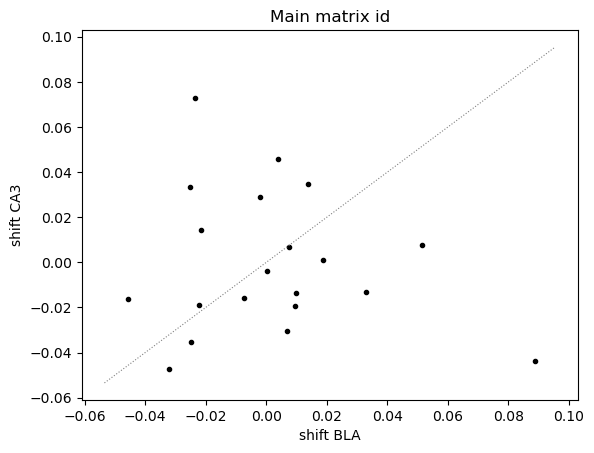

In [46]:
#plt.figure(figursize= (10,10))

#print(all_mms)
for m in all_mms:
    x = shift_BLA['BLA',m]
    y  = shift_CA3['CA3',m]
    #if m in ['M1', 'M4', 'M6','M11','M14','M17','M7']:
    #    mark = '>'
    #elif m in ['M2', 'M3', 'M9', 'M15', 'M16', 'M18','M10']:
    #    mark = '<'
    #else:
    #    mark = '.'
    #plt.plot(x,y,mark,label=m)
    plt.plot(x,y,'.k')

ax = plt.gca()
lim_min = min(ax.get_xlim()[0], ax.get_ylim()[0])
lim_max = max(ax.get_xlim()[1], ax.get_ylim()[1])
plt.plot([lim_min, lim_max], [lim_min, lim_max],
         color='gray', linewidth=0.8, linestyle=':', label='y = x')
plt.title('Main matrix id')
plt.xlabel('shift BLA')
plt.ylabel('shift CA3')
#plt.legend()
plt.show()